In [25]:
import os
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import requests
import requests_cache
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from nyc_api import fetch_311_weekly_by_board, iso_week_period

In [26]:
START_DATE = '2021-01-01'
END_DATE = datetime.now(timezone.utc).strftime('%Y-%m-%d')
WEEKLY_PATH = '../data/01_raw/311_weekly_by_board.parquet'

if os.path.exists(WEEKLY_PATH):
    df = pd.read_parquet(WEEKLY_PATH)
    print(f'Loaded {len(df):,} (board, week) rows from cache')
else:
    df = fetch_311_weekly_by_board(START_DATE, END_DATE)
    df.to_parquet(WEEKLY_PATH)

print(f'{len(df):,} rows  |  {df["year_week"].nunique()} weeks  |  {df["community_board"].nunique()} boards')

Loaded 22,238 (board, week) rows from cache
22,238 rows  |  291 weeks  |  78 boards


In [27]:
EVENTS_AGG_PATH = '../data/01_raw/events_agg_multiyear.parquet'
INCLUDE_TYPES = [
    'Parade', 'Street Festival', 'Single Block Festival', 'Block Party',
    'Farmers Market', 'Street Event', 'Religious Event', 'Plaza Event',
    'Plaza Partner Event', 'Athletic Race / Tour', 'Open Street Partner Event',
    'Health Fair', 'Sidewalk Sale',
]

if os.path.exists(EVENTS_AGG_PATH):
    events_agg = pd.read_parquet(EVENTS_AGG_PATH)
    print(f'Loaded {len(events_agg):,} aggregated event groups from cache')
else:
    type_list = ','.join(f"'{t}'" for t in INCLUDE_TYPES)
    where = (
        f"start_date_time <= '{END_DATE}'"
        f" and end_date_time >= '{START_DATE}'"
        f" and event_type in({type_list})"
    )
    select = (
        'community_board, event_borough, '
        'date_extract_y(start_date_time) as syr, date_extract_m(start_date_time) as smo, '
        'date_extract_woy(start_date_time) as swoy, '
        'date_extract_y(end_date_time) as eyr, date_extract_m(end_date_time) as emo, '
        'date_extract_woy(end_date_time) as ewoy, count(*) as n'
    )
    group = 'community_board, event_borough, syr, smo, swoy, eyr, emo, ewoy'
    session = requests_cache.CachedSession('../data/00_cache/events', expire_after=3600)
    r = session.get('https://data.cityofnewyork.us/resource/bkfu-528j.json',
                    params={'$select': select, '$where': where, '$group': group, '$limit': '50000'},
                    timeout=120)
    r.raise_for_status()
    events_agg = pd.DataFrame(r.json())
    events_agg.to_parquet(EVENTS_AGG_PATH)
    print(f'Fetched and saved {len(events_agg):,} aggregated event groups')

Loaded 16,859 aggregated event groups from cache


In [28]:
events_agg = events_agg.dropna(subset=['community_board', 'event_borough']).copy()
for col in ['syr', 'smo', 'swoy', 'eyr', 'emo', 'ewoy', 'n']:
    events_agg[col] = events_agg[col].astype(int)

events_agg['boards'] = events_agg['community_board'].str.split(',')
events_agg = events_agg.explode('boards')
events_agg['boards'] = events_agg['boards'].str.strip()
events_agg = events_agg[events_agg['boards'].str.fullmatch(r'\d{1,2}')]
events_agg['board_key'] = events_agg['boards'].str.zfill(2) + ' ' + events_agg['event_borough'].str.upper()

events_agg['week_start'] = events_agg.apply(lambda r: iso_week_period(r['syr'], r['smo'], r['swoy']), axis=1)
events_agg['week_end'] = events_agg.apply(lambda r: iso_week_period(r['eyr'], r['emo'], r['ewoy']), axis=1)

start_ord = events_agg['week_start'].astype('int64').values
end_ord = events_agg['week_end'].astype('int64').values
n_weeks = end_ord - start_ord + 1
rep_idx = np.repeat(np.arange(len(events_agg)), n_weeks)
week_offset = np.concatenate([np.arange(n) for n in n_weeks])
events_exp = events_agg.iloc[rep_idx].reset_index(drop=True)
events_exp['year_week'] = events_exp['week_start'].values + week_offset

event_counts = events_exp.groupby(['board_key', 'year_week'])['n'].sum().reset_index(name='event_count')
print(f'{len(event_counts):,} (board, week) rows with event activity')

13,556 (board, week) rows with event activity


In [29]:
LAT, LON = 40.7812, -73.9665
DAILY_VARS = 'temperature_2m_max,temperature_2m_min,rain_sum,snowfall_sum'

def fetch_weather(base_url, path):
    if os.path.exists(path):
        return pd.read_parquet(path)
    r = requests.get(base_url, params={
        'latitude': LAT, 'longitude': LON, 'start_date': START_DATE, 'end_date': END_DATE,
        'daily': DAILY_VARS, 'timezone': 'America/New_York',
    }, timeout=60)
    r.raise_for_status()
    w = pd.DataFrame(r.json()['daily'])
    w['time'] = pd.to_datetime(w['time'])
    w.to_parquet(path)
    return w

weather_actual = fetch_weather('https://archive-api.open-meteo.com/v1/archive',
                               '../data/01_raw/weather_actual_multiyear.parquet')
weather_forecast = fetch_weather('https://historical-forecast-api.open-meteo.com/v1/forecast',
                                 '../data/01_raw/weather_forecast_multiyear.parquet')
print(f'actual: {len(weather_actual):,} days  |  forecast: {len(weather_forecast):,} days')

actual: 2,032 days  |  forecast: 2,032 days


In [30]:
def weekly_agg(w):
    w = w.copy()
    w['year_week'] = w['time'].dt.to_period('W')
    return w.groupby('year_week').agg(
        temp_max=('temperature_2m_max', 'max'),
        temp_min=('temperature_2m_min', 'min'),
        had_rain=('rain_sum', lambda s: int((s > 0).any())),
        had_snow=('snowfall_sum', lambda s: int((s > 0).any())),
    ).reset_index()

weekly_actual = weekly_agg(weather_actual)
weekly_forecast = weekly_agg(weather_forecast)

lag1_weather = weekly_actual.rename(columns={
    'temp_max': 'lag1_temp_max', 'temp_min': 'lag1_temp_min',
    'had_rain': 'lag1_had_rain', 'had_snow': 'lag1_had_snow',
}).copy()
lag1_weather['year_week'] = lag1_weather['year_week'] + 1

pred_weather = weekly_forecast.rename(columns={
    'temp_max': 'pred_temp_max', 'temp_min': 'pred_temp_min',
    'had_rain': 'pred_had_rain', 'had_snow': 'pred_had_snow',
})

print(f'lag1_weather: {len(lag1_weather):,} weeks  |  pred_weather: {len(pred_weather):,} weeks')

lag1_weather: 291 weeks  |  pred_weather: 291 weeks


In [31]:
counts = df.rename(columns={'community_board': 'board_key'}).sort_values(['board_key', 'year_week']).copy()
counts['week_of_year'] = counts['year_week'].apply(lambda w: w.start_time.isocalendar().week)
counts['lag_1'] = counts.groupby('board_key')['calls'].shift(1)
counts['lag_2'] = counts.groupby('board_key')['calls'].shift(2)

counts = counts.merge(event_counts, on=['board_key', 'year_week'], how='left')
counts['event_count'] = counts['event_count'].fillna(0)

counts = counts.merge(lag1_weather, on='year_week', how='left')
counts = counts.merge(pred_weather, on='year_week', how='left')

data = counts.dropna(subset=['lag_1', 'lag_2', 'lag1_temp_max', 'pred_temp_max']).copy()
print(f'{len(data):,} (board, week) rows with full lag history')

22,083 (board, week) rows with full lag history


In [32]:
FEATURES = [
    'week_of_year', 'lag_1', 'lag_2', 'event_count',
    'lag1_temp_max', 'lag1_temp_min', 'lag1_had_rain', 'lag1_had_snow',
    'pred_temp_max', 'pred_temp_min', 'pred_had_rain', 'pred_had_snow',
]

weeks_sorted = sorted(data['year_week'].unique())
split_idx = int(len(weeks_sorted) * 0.8)
train_weeks = weeks_sorted[:split_idx]
test_weeks = weeks_sorted[split_idx:]

train = data[data['year_week'].isin(train_weeks)]
test = data[data['year_week'].isin(test_weeks)]

X_train, y_train = train[FEATURES], train['calls']
X_test, y_test = test[FEATURES], test['calls']
print(f'train: {len(train):,}  test: {len(test):,}')

train: 17,647  test: 4,436


In [33]:
model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Model MAE:    131.34
Model RMSE:   394.49
Baseline MAE: 131.73  (predict calls = last week)


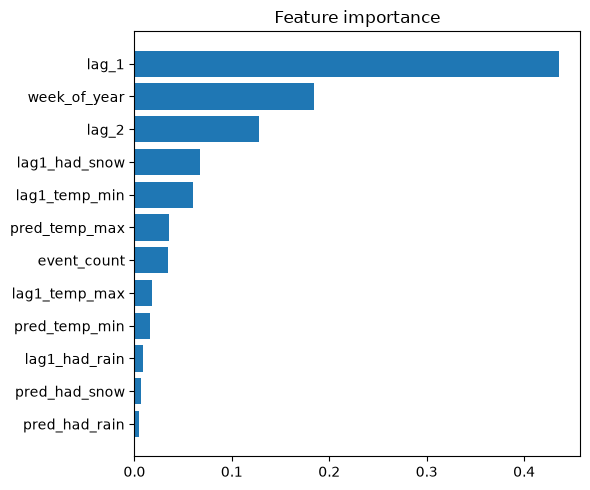

In [34]:
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
baseline_mae = mean_absolute_error(y_test, X_test['lag_1'])

print(f'Model MAE:    {mae:.2f}')
print(f'Model RMSE:   {rmse:.2f}')
print(f'Baseline MAE: {baseline_mae:.2f}  (predict calls = last week)')

hover = [
    f'<b>board {b}</b><br>week: {w}<br>actual: {a:.0f}<br>predicted: {p:.0f}<br>events: {e:.0f}'
    f'<br>pred temp: {tmin:.0f}–{tmax:.0f}°C<br>rain: {rain}  snow: {snow}'
    for b, w, a, p, e, tmin, tmax, rain, snow in zip(
        test['board_key'], test['year_week'].astype(str), y_test, pred, X_test['event_count'],
        X_test['pred_temp_min'], X_test['pred_temp_max'],
        X_test['pred_had_rain'], X_test['pred_had_snow'],
    )
]

fig = go.Figure()
lims = [0, max(y_test.max(), pred.max())]
fig.add_trace(go.Scatter(x=lims, y=lims, mode='lines',
                         line=dict(color='black', width=1), showlegend=False, hoverinfo='skip'))
fig.add_trace(go.Scatter(x=y_test, y=pred, mode='markers',
                         marker=dict(size=6, opacity=0.5, color='#2563eb'),
                         text=hover, hoverinfo='text', showlegend=False))
fig.update_layout(
    title='Actual vs predicted (test set)',
    xaxis_title='Actual calls', yaxis_title='Predicted calls',
    width=650, height=550,
)
fig.show()

importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(importance.index, importance.values)
ax.set_title('Feature importance')
plt.tight_layout()
plt.show()

In [35]:
K = 5

rank_df = test[['board_key', 'year_week', 'calls']].copy()
rank_df['pred'] = pred

def week_metrics(g):
    actual_sorted = g.sort_values('calls', ascending=False)
    pred_sorted = g.sort_values('pred', ascending=False)
    actual_top = set(actual_sorted['board_key'].head(K))
    pred_top = list(pred_sorted['board_key'].head(K))

    hits = len(set(pred_top) & actual_top)
    precision = hits / K
    recall = hits / len(actual_top)

    rel = dict(zip(g['board_key'], g['calls']))
    dcg = sum(rel[b] / np.log2(i + 2) for i, b in enumerate(pred_top))
    idcg = sum(v / np.log2(i + 2) for i, v in enumerate(actual_sorted['calls'].head(K)))
    ndcg = dcg / idcg if idcg > 0 else 0.0

    top1_board = actual_sorted['board_key'].iloc[0]
    rr = 1 / (pred_top.index(top1_board) + 1) if top1_board in pred_top else 0.0

    return pd.Series({'precision': precision, 'recall': recall, 'ndcg': ndcg, 'mrr': rr, 'n_boards': len(g)})

weekly_metrics = rank_df.groupby('year_week').apply(week_metrics, include_groups=False)
weekly_metrics = weekly_metrics[weekly_metrics['n_boards'] >= K]

print(f'Weeks evaluated: {len(weekly_metrics):,}')
print(f'Precision@{K}: {weekly_metrics["precision"].mean():.3f}')
print(f'Recall@{K}:    {weekly_metrics["recall"].mean():.3f}')
print(f'NDCG@{K}:      {weekly_metrics["ndcg"].mean():.3f}')
print(f'MRR@{K}:       {weekly_metrics["mrr"].mean():.3f}')

Weeks evaluated: 58
Precision@5: 0.676
Recall@5:    0.676
NDCG@5:      0.933
MRR@5:       0.593
